## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## LOAD DATASET

In [2]:
df = pd.read_csv('global_youtube_creator_data_large.csv')
print(df.head())
print(df.info())
print(df.describe())



             timestamp    video_id      category  language region  \
0  2024-09-14 05:08:02  VID_589765         Vlogs  Japanese     PK   
1  2025-08-09 12:23:26  VID_577279  Tech Reviews      Urdu     UK   
2  2024-03-04 14:39:48  VID_890301        Gaming   English     BR   
3  2025-05-04 11:05:26  VID_613444     Education      Urdu     PK   
4  2024-09-22 20:22:31  VID_602671        Gaming  Japanese     IN   

   duration_sec  views  likes  comments  shares  sentiment_score  ads_enabled  
0           873   6826    396        34      31           -0.082         True  
1          2335  11371    402        26      19           -0.873        False  
2          1895   7509    730        45      25           -0.764         True  
3           841  17361   1302       122      25           -0.788         True  
4          1246  18494    756        63      42            0.521        False  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 col

## DATA CLEANING

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour


In [4]:
print(df.isnull().sum())

timestamp          0
video_id           0
category           0
language           0
region             0
duration_sec       0
views              0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
year               0
month              0
day                0
hour               0
dtype: int64


## EDA

## Check which category is popular 

In [5]:
df['category'].value_counts()

category
Vlogs           167383
Education       167073
Coding          166609
Gaming          166401
Music           166381
Tech Reviews    166153
Name: count, dtype: int64

## Check country create more views 

In [6]:
df['region'].value_counts()

region
US    200518
PK    200479
BR    200202
IN    199673
UK    199128
Name: count, dtype: int64

## Check which language dominate 

In [7]:
df['language'].value_counts()

language
English     200560
Hindi       200362
Urdu        199887
Spanish     199650
Japanese    199541
Name: count, dtype: int64

## Top performing categories - Check best content type 

In [8]:
df.groupby('category')['views'].sum().sort_values(ascending=False)

category
Vlogs           1679298599
Education       1670642889
Music           1669528052
Tech Reviews    1666029523
Gaming          1663927297
Coding          1663160692
Name: views, dtype: int64

## Region vs Views - Check which country perform best 

In [9]:
df.groupby('region')['views'].sum().sort_values(ascending=False)

region
US    2008898713
PK    2007481705
IN    2002027542
BR    1997321409
UK    1996857683
Name: views, dtype: int64

## Ads impact - Check perform about ads enable video 

In [10]:
df.groupby('ads_enabled')['views'].mean()

ads_enabled
False     9993.864222
True     10017.262261
Name: views, dtype: float64

## Best upload hour - Get idea about best upload time 

<Axes: xlabel='hour'>

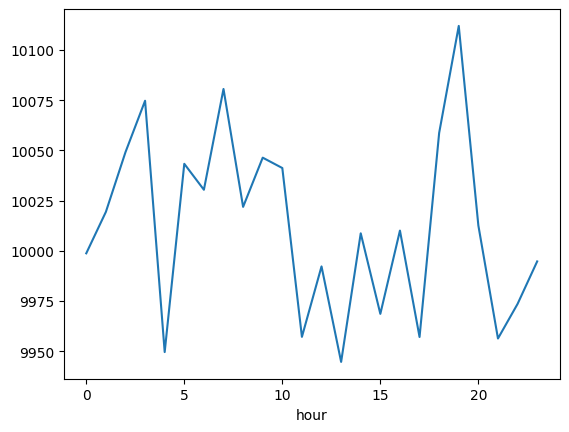

In [11]:
df.groupby('hour')['views'].mean().plot()

## Monthly trend - Get Idea about monthly views 

<Axes: xlabel='month'>

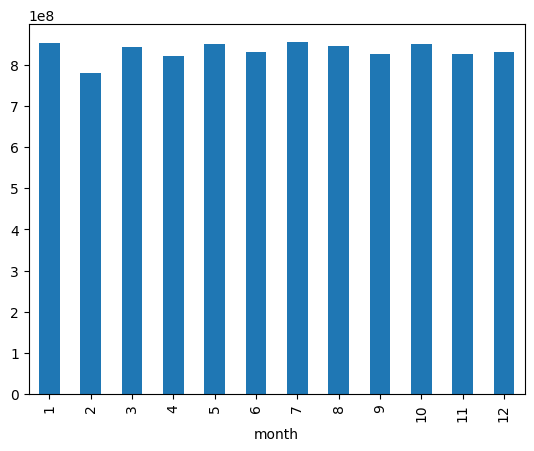

In [12]:
df.groupby('month')['views'].sum().plot(kind='bar')

## Sentiment vs Engagement - Check positive videos performance  

In [13]:
df['engagement'] = (df['likes'] + df['comments'] + df['shares']) / df['views']

df[['sentiment_score','engagement']].corr()

,sentiment_score,engagement
sentiment_score,1.000000,-0.000117
engagement,-0.000117,1.000000


## Find what actually affects engagement

In [16]:
df.groupby('category')['engagement'].mean().sort_values(ascending=False)


category
Gaming          0.064077
Vlogs           0.064014
Music           0.064013
Tech Reviews    0.064003
Coding          0.063882
Education       0.063849
Name: engagement, dtype: float64

<Axes: xlabel='hour'>

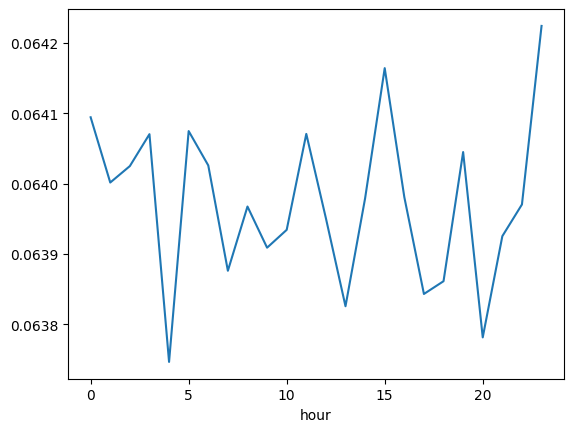

In [17]:
df.groupby('hour')['engagement'].mean().plot()


In [18]:

df.groupby('region')['engagement'].mean()

region
BR    0.063941
IN    0.064014
PK    0.063942
UK    0.064003
US    0.063966
Name: engagement, dtype: float64

## Gaming engagement confirm

In [19]:
df[df['category'] == 'Gaming']['engagement'].mean()

np.float64(0.06407707410704483)

In [20]:
df.groupby('region')['engagement'].mean().sort_values(ascending=False)

region
IN    0.064014
UK    0.064003
US    0.063966
PK    0.063942
BR    0.063941
Name: engagement, dtype: float64

## BR region confirm

In [21]:
df[df['region'] == 'BR']['engagement'].mean()

np.float64(0.06394071467646571)

In [22]:
df.groupby('region')['engagement'].mean().sort_values(ascending=False)

region
IN    0.064014
UK    0.064003
US    0.063966
PK    0.063942
BR    0.063941
Name: engagement, dtype: float64

## Category engagement chart

<Axes: xlabel='category'>

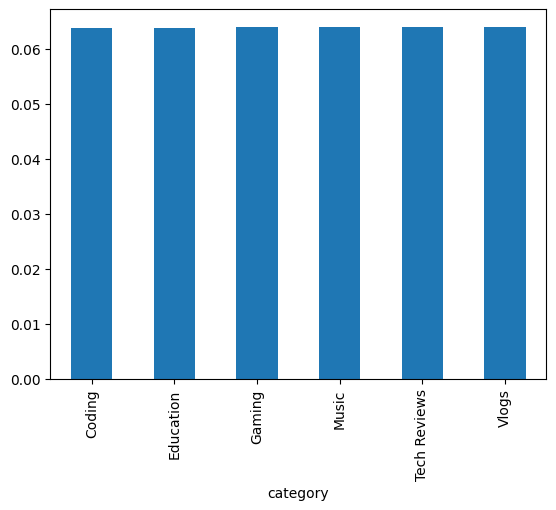

In [23]:
df.groupby('category')['engagement'].mean().plot(kind='bar')

## Region engagement chart

<Axes: xlabel='region'>

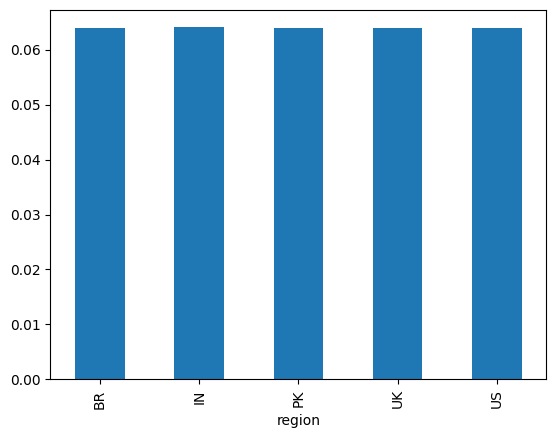

In [25]:
df.groupby('region')['engagement'].mean().plot(kind='bar')

## Best category + region combo

In [26]:
df.groupby(['category','region'])['engagement'].mean().sort_values(ascending=False)

category      region
Gaming        PK        0.064269
Vlogs         US        0.064188
Music         US        0.064177
Gaming        IN        0.064125
Vlogs         IN        0.064124
Coding        BR        0.064123
Gaming        US        0.064108
Music         IN        0.064108
Tech Reviews  BR        0.064092
              IN        0.064078
Coding        UK        0.064066
Vlogs         UK        0.064058
Tech Reviews  UK        0.064048
Music         UK        0.064004
              PK        0.063987
Gaming        UK        0.063969
Tech Reviews  US        0.063959
Education     BR        0.063948
              IN        0.063936
Vlogs         PK        0.063922
Gaming        BR        0.063915
Coding        PK        0.063891
Education     UK        0.063873
Tech Reviews  PK        0.063838
Music         BR        0.063791
Vlogs         BR        0.063777
Education     US        0.063744
              PK        0.063743
Coding        IN        0.063716
              US      

## Check Top 5 combinations

In [27]:
df.groupby(['category','region'])['engagement'].mean().sort_values(ascending=False).head(5)

category  region
Gaming    PK        0.064269
Vlogs     US        0.064188
Music     US        0.064177
Gaming    IN        0.064125
Vlogs     IN        0.064124
Name: engagement, dtype: float64

## Visualize it

<Axes: xlabel='category,region'>

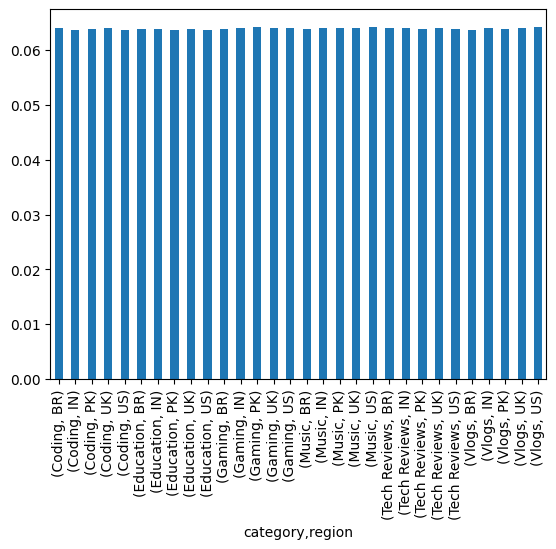

In [28]:
df.groupby(['category','region'])['engagement'].mean().plot(kind='bar')